In [1]:
from modulo_input_modelo import crear_input, Transicion_flota_modelo, tam_bat
import pandas as pd
from gurobipy import Model, GRB, quicksum 
import numpy as np

In [2]:
# Lectura de parámetros iniciales, estado de la flota actual y su operación
datos = pd.read_excel('input_EPMTPQ.xlsx',sheet_name=None)

# Definición del Caso Base
params = {'fin_horizonte': True, 'presupuesto': [True,25000000], 'emisiones': True, 'contenedores': True, 'edad_media': True,
          'reduccion_anual_precio_bateria': 0.12, 'Precio_Elect_Noche': 0.073, 'Precio_Elect_Dia': 0.084,
          'rho_N': 0.75, 'Precio_diesel': 0.44, 'Periodos': 26, 'Tasa_redu_emisiones': 1/26,'mantenimiento_elec_ahorro': 6/10,
          'escenario': 0,'sensi_combus':[True,False]} # Caso Base

params_exp = params
L,CT,T,K,J_K,J_K_tilde,K_E,K_R,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,o_inv,o_techo,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,Theta_tilde,var_epsilon,c_tilde,costo_kwh,cost_bus_sin_bat,efic_bus,DA,epsilon,rho_N,PE_N = crear_input(datos,params_exp)

Costo de baterias Schmidt


In [3]:
# Determinar en que año ya se encuentra tod ala flota electrificada o el 50%
def indicadores(q,R, T, K_E, J_K, z, mo):
    anio_50 = None
    anio_100 = None
    total_flota = sum(q[r] for r in R)
    flag = True
    for t in T:
        num_buses = sum( z[k,t,j-1].x for k in K_E for j in J_K[k] if j != 0)
        if num_buses >= 0.5 * np.ceil(total_flota) and flag:
            anio_50 = t
            flag = False
        if num_buses == total_flota:
            anio_100 = t
            break
    indicadores = {'Funcion Objetivo': round(mo.ObjVal,3), 'Numero años 50 electrificado': anio_50, 'Numero años 100 electrificado': anio_100, 'Tiempo de Solucion': round(mo.Runtime,2)}
    return indicadores

In [4]:
mo = Model()
mo.Params.OutputFlag = 1
# Variables
u = mo.addVars(CT,T,name='u',vtype='I', lb= 0) # I
v = mo.addVars(CT,T,name='v',vtype='I', lb= 0) # I
x = mo.addVars( K,T,name='x',vtype='I', lb= 0) # I
b = mo.addVars(T   ,name='b',vtype='C', lb= 0) # C
w_diesel = {}
w_energia = {}

u_tilde = mo.addVars(T,name='u',vtype='I', lb= 0) # I
v_tilde = mo.addVars(T,name='v',vtype='I', lb= 0) # I

if params['contenedores'] == False:
    u_tilde.ub = 0
    v_tilde.ub = 0

y = {}; [y.update(mo.addVars([k],T,[j]  , name= 'y',vtype= 'I', lb= 0)) for k in K for j in J_K[k] if j != 0]; # I
z = {}; [z.update(mo.addVars([k],T,[j-1], name= 'z',vtype= 'I', lb= 0)) for k in K for j in J_K[k] if j != 0]; # I
w = {}; [w.update(mo.addVars([k],R,T,[j], name= 'w',vtype= 'I', lb =0)) for k in K for j in J_K_tilde[k]    ]; # I
mo.update()
vars   = ['u','v','x','b','u_tilde','v_tilde','y','z','w']
# Funcion objetivo

w_diesel = mo.addVar(name='w_diesel',vtype='C', lb= 0) # C
w_energia = mo.addVar(name='w_energia',vtype='C', lb= 0) # C

mo.addConstr( w_diesel == 
        quicksum( 
                (beta**( (t_+1) -1) * (1/efic_bus[k]) * DA[r]) * w[k,r,t,j]
                for t_,t in enumerate(T) 
                for k in K if k not in K_E 
                for r in R 
                for j in range(0, (kappa[k]) +1) 
                )
        + 
        quicksum( 
                (beta**( num_per + i - 1 ) * (1/efic_bus[k]) * DA[r]) * w[k,r,t_F,j]
                for k in K if k not in K_E 
                for r in R 
                for j in range(0, (kappa[k]-1) +1)
                for i in range(1, (kappa[k]-j) +1)
                ), name='R-diesel_');
        
mo.addConstr( w_energia == 
        quicksum( 
                beta**( (t_+1) -1) * DA[r] *  
                ( 
                  quicksum( (1/efic_bus[k]) * w[k,r,t,j] for k in K_E if k not in K_R for j in range(0, (kappa[k]) +1) ) +
                  quicksum( (1/efic_bus[k]) * (1 + epsilon - (rho_N*epsilon) ) * w[k,r,t,j] for k in K_R for j in range(0, (kappa[k]) +1) )
                )
                for t_,t in enumerate(T) 
                for r in R
                )
        +
        quicksum( DA[r] *  
                ( 
                  quicksum( beta**( num_per + i - 1 ) * (1/efic_bus[k]) * w[k,r,t_F,j] 
                          for k in K_E if k not in K_R 
                          for j in range(0, (kappa[k]-1) +1)
                          for i in range(1, (kappa[k]-j) +1) )
                  +
                  quicksum( beta**( num_per + i - 1 ) * (1/efic_bus[k]) * (1 + epsilon - (rho_N*epsilon) ) * w[k,r,t_F,j] 
                          for k in K_R 
                          for j in range(0, (kappa[k]-1) +1)
                          for i in range(1, (kappa[k]-j) +1) )
                )
                for r in R
                ), name='R-energia_')
        

mo.setObjective(
            quicksum( beta**( (t_+1) -1) * quicksum( f[k,t] * x[k,t] 
                                          - quicksum( s[k,j] * y[k,t,j]  for j in range(1, (kappa[k]+1) +1))
                                          + quicksum( o_inv[k,r,t,j] * w[k,r,t,j] for r in R for j in range(0, (kappa[k]) +1))
                                          + mc[k,t] * z[k,t,alpha[k]]
                                        for k in K)  
                    for t_,t in enumerate(T) )
          
            +quicksum( beta**( (t_+1) -1) * quicksum( p[c] * u[c,t] + F * g[c] * v[c,t] for c in CT) for t_,t in enumerate(T) )
            +quicksum( beta**( (t_+1) -1) * p_tilde * u_tilde[t] for t_,t in enumerate(T) )
            
            +quicksum( beta**( num_per + i - 1 ) * o_inv[k,r,t_F,j+i] * w[k,r,t_F,j]
                      for k in K for r in R for j in range(0, (kappa[k]-1) +1) for i in range(1, (kappa[k]-j) +1) ) 
            - quicksum( beta**( num_per + kappa[k] - j ) * s[k,kappa[k]+1] * z[k,t_F,j] for k in K for j in range(0, (kappa[k]) +1) ) 
            + quicksum( beta**( num_per + alpha[k] - j - 1 ) * mc[k,t_F] * z[k,t_F,j] for k in K for j in range(0, (alpha[k]-1) +1 ) )
            + params['Precio_diesel']*w_diesel + params['Precio_Elect_Noche']* w_energia
            , GRB.MINIMIZE)
'''
mo.setObjective( quicksum( beta**( (t_+1) -1) * b[t] for t_,t in enumerate(T) ) , GRB.MINIMIZE)
'''
# Restricciones

mo.addConstrs( ( quicksum( w[k,r,t,j]  for k in K for j in range(0,kappa[k] + 1)) == q[r]  for r in R for t in T), name='R-2_');

mo.addConstrs( ( w[k,r,t,j] <= h[k,r,t,j] * z[k,t,j] for k in K for r in R for t in T for j in J_K_tilde[k] ), name='R-3_');

mo.addConstrs( ( quicksum( w[k,r,t,j]  for r in R) == z[k,t,j] for k in K for t in T for j in J_K_tilde[k] ), name='R-4_');

mo.addConstrs( ( x[k,t] == z[k,t,0] for k in K for t in T if t != t1), name='R-5_');

mo.addConstrs( ( x[k,t1] + a[k,0] == z[k,t1,0] for k in K ), name='R-6_');

mo.addConstrs( ( z[k,t,j] == z[k,t-1,j-1] - y[k,t,j] for k in K for t in T if t != t1 for j in J_K_tilde[k] if j != 0 ), name='R-7_');

mo.addConstrs( ( z[k,t1,j] == a[k,j] - y[k,t1,j] for k in K for j in J_K_tilde[k] if j != 0), name='R-8_');

mo.addConstrs( ( y[k,t,(kappa[k]+1)] == z[k,t-1,kappa[k]] for k in K for t in T if t != t1), name='R-9_');

mo.addConstrs( ( y[k,t1,(kappa[k]+1)] == a[k,kappa[k]+1] for k in K ), name='R-10_');

mo.addConstrs( ( v[c,t1] == e[c] + u[c,t1] for c in CT ), name='R-11_');

mo.addConstrs( (  v[c,t] == v[c,t-1] + u[c,t] for t in T if t != t1 for c in CT ), name='R-12_');

if params['edad_media']:
    mo.addConstr(  quicksum( j * z[k,t_F,j] for k in K for j in range(0,(kappa[k]) +1)) <= 
                    Gamma * quicksum( z[k,t_F,j] for k in K for j in range(0,(kappa[k]) +1)) , name='R-13_');

mo.addConstrs( ( v[c,t] + v[c_tilde,t] >= theta[c] * quicksum( z[k,t,j] for k in K_E if c in C[k] for j in range(0, (kappa[k]) +1)) 
                for c in CT if c != c_tilde for t in T ), name='R-14_');

mo.addConstrs( ( quicksum( f[k,t] * x[k,t] - quicksum( s[k,j] * y[k,t,j] for j in range(1, (kappa[k]+1) + 1)) for k in K)
            + quicksum( p[c] * u[c,t] for c in CT)
            + p_tilde * u_tilde[t] == b[t]   for t in T ), name='R-15_');

mo.addConstr(    v_tilde[t1] == e_tilde + u_tilde[t1] , name='R-16_');

mo.addConstrs( ( v_tilde[t] == v_tilde[t-1] + u_tilde[t] for t in T if t != t1 ), name='R-17');

mo.addConstrs( ( v[c_tilde,t] <= theta_tilde * v_tilde[t] for t in T ), name='R-18');

if params['presupuesto'][0]:
    mo.addConstr( quicksum( beta**( (t_+1) -1) * b[t] for t_,t in enumerate(T) ) <= B, name='R-19_');

if params['emisiones']:
    mo.addConstrs( ( quicksum( var_epsilon[(k,j,r,l)] * w[k,r,t,j]  for k in K for j in range(0,kappa[k] + 1) for r in R) <= Theta[(l,t)] 
                for t in T for l in L ), name='R-20');

# mo.addConstrs( ( quicksum( g[c] * v[c,t] for c in DC) <= G for t in T if np.char.isnumeric(G) ), name='R-14_');

# mo.addConstrs( ( quicksum( v[c,t] for c in DC) <= H for t in T if np.char.isnumeric(H) ), name='R-15_');

#mo.Params.MIPGap = 0
mo.update()
mo.optimize()
#mo.write('output_B_min.sol')
#print(mo.Status)
#mo.computeIIS()
#mo.write('infactible.ilp')

Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-19
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-9700K CPU @ 3.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 22468 rows, 22206 columns and 111122 nonzeros
Model fingerprint: 0xca9a3697
Variable types: 28 continuous, 22178 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-02, 1e+06]
  Objective range  [7e-02, 8e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+07]
Presolve removed 18984 rows and 7978 columns
Presolve time: 0.10s
Presolved: 3484 rows, 14228 columns, 35556 nonzeros
Variable types: 0 continuous, 14228 integer (72 binary)

Root relaxation: objective 4.336222e+07, 18738 iterations, 0.34 seconds (0.52 work units)

    Nodes    |    Current Node    |     Objectiv

In [5]:
B_min = 13417186
presu =  [B_min * (1 + (i/10)) for i in range(0,11)]

In [6]:
def actualizar(i, mo):
    mo.getConstrByName('R-19_').RHS = i
    mo.optimize()
    return mo

In [7]:
from alive_progress import alive_bar
data = {}
mo.Params.TimeLimit = 600
mo.read('output_B_min.sol')
with alive_bar(len(presu), force_tty=True) as bar:
    for i in presu:
        mo.Params.OutputFlag = 1
        print(f'Presupuesto: {i}')
        mo = actualizar(i, mo)
        indicadores_ = indicadores(q, R, T, K_E, J_K, z, mo)
        data[i] = indicadores_
        bar()

Set parameter TimeLimit to value 600
Read solution from file output_B_min.sol
on 0: Set parameter OutputFlag to value 1                                       
on 0: Presupuesto: 13417186.0                                                   
on 0: Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))
                                                                                
on 0: CPU model: Intel(R) Core(TM) i7-9700K CPU @ 3.60GHz, instruction set [SSE2|AVX|AVX2]
on 0: Thread count: 8 physical cores, 8 logical processors, using up to 8 threads
                                                                                
on 0: Non-default parameters:                                                   
on 0: TimeLimit  600                                                            
                                                                                
on 0: Optimize a model with 22468 rows, 22206 columns and 111122 nonzeros       
on 0: Model f

In [9]:
data

{13417186.0: {'Funcion Objetivo': 45332347.097,
  'Numero años 50 electrificado': 2038,
  'Numero años 100 electrificado': 2050,
  'Tiempo de Solucion': 589.92},
 14758904.600000001: {'Funcion Objetivo': 44235197.513,
  'Numero años 50 electrificado': 2035,
  'Numero años 100 electrificado': 2044,
  'Tiempo de Solucion': 600.15},
 16100623.2: {'Funcion Objetivo': 43821215.841,
  'Numero años 50 electrificado': 2034,
  'Numero años 100 electrificado': 2037,
  'Tiempo de Solucion': 600.28},
 17442341.8: {'Funcion Objetivo': 43712528.937,
  'Numero años 50 electrificado': 2033,
  'Numero años 100 electrificado': 2036,
  'Tiempo de Solucion': 5.59},
 18784060.4: {'Funcion Objetivo': 43712528.937,
  'Numero años 50 electrificado': 2033,
  'Numero años 100 electrificado': 2036,
  'Tiempo de Solucion': 3.9},
 20125779.0: {'Funcion Objetivo': 43712528.937,
  'Numero años 50 electrificado': 2033,
  'Numero años 100 electrificado': 2036,
  'Tiempo de Solucion': 3.74},
 21467497.6: {'Funcion Obje

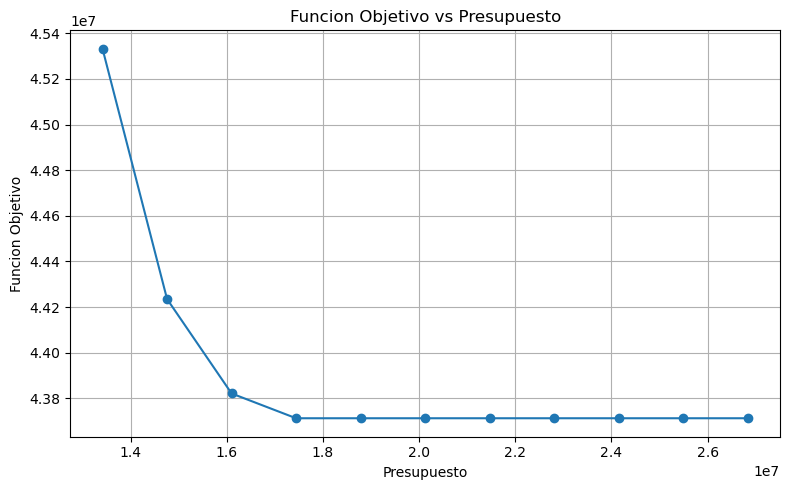

In [12]:
import matplotlib.pyplot as plt

def graficar(diccionario, variable_y, tipo="contra_presupuesto"):
    presupuestos = list(diccionario.keys())
    valores_y = [diccionario[p][variable_y] for p in presupuestos]

    plt.figure(figsize=(8, 5))

    plt.plot(presupuestos, valores_y, marker='o', linestyle='-')
    plt.xlabel("Presupuesto")
    plt.ylabel(variable_y)
    plt.title(f"{variable_y} vs Presupuesto")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Ejemplo: graficar función objetivo vs presupuesto
graficar(data, 'Funcion Objetivo', tipo="contra_presupuesto")


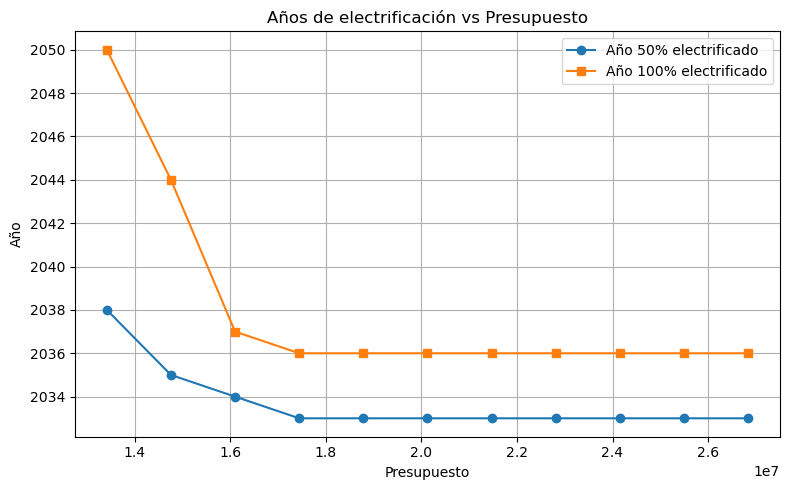

In [14]:
import matplotlib.ticker as ticker

def graficar_anios_electrificados_sin_decimales(diccionario):
    presupuestos = list(diccionario.keys())
    anio_50 = [diccionario[p]['Numero años 50 electrificado'] for p in presupuestos]
    anio_100 = [diccionario[p]['Numero años 100 electrificado'] for p in presupuestos]

    plt.figure(figsize=(8, 5))
    plt.plot(presupuestos, anio_50, 'o-', label='Año 50% electrificado')
    plt.plot(presupuestos, anio_100, 's-', label='Año 100% electrificado')

    plt.xlabel("Presupuesto")
    plt.ylabel("Año")
    plt.title("Años de electrificación vs Presupuesto")
    plt.legend()
    plt.grid(True)

    # Forzar a que el eje Y tenga solo enteros
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

# Generar el gráfico sin decimales en el eje Y
graficar_anios_electrificados_sin_decimales(data)

